# Netflix Analysis Project

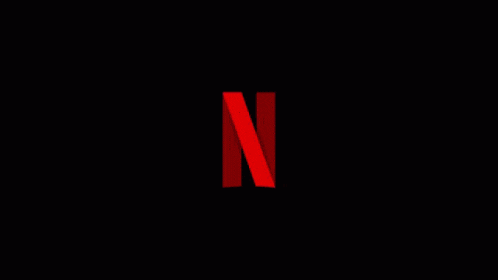

# **Project Summary**
- This project aims to analyze and cluster Netflix's vast content library using data science techniques, focusing on TV shows and movies available on the platform. The dataset includes rich metadata such as title, type, genre, release year, country, rating, and description. Through exploratory data analysis (EDA) and clustering, the goal is to uncover hidden patterns and trends that can help Netflix better understand its content distribution, genre popularity, and regional preferences.

---

# **Problem Statement**
- With thousands of titles available, Netflix faces the challenge of efficiently organizing and recommending content to a global audience. The diversity of genres, inconsistent metadata, and the growing volume of international content make it essential to identify meaningful groupings within the content library for improved curation and personalized recommendations.

---

# **Business Objective**
- The objective is to use clustering (K-Means) and dimensionality reduction (PCA) to segment content based on genres and other features. These clusters can inform Netflix's content strategy, improve recommendation systems, and identify gaps or oversaturation in certain categories.

---

# **General Guidelines**
- Use Python, Pandas, and Plotly for data analysis and visualization.

- Perform data cleaning and transformation.

- Apply TF-IDF vectorization on genres.

- Visualize clusters using PCA and Plotly for business insights.

In [24]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [25]:
# 2. Load Dataset
df = pd.read_csv("NETFLIX MOVIES AND TV SHOWS CLUSTERING.csv")
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   object
 10  listed_in     7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(1), object(11)
memory usage: 730.2+ KB


In [27]:
# Dataset Rows & Columns count
df.shape

(7787, 12)

In [28]:
# Count of Duplicate Value
df.duplicated().sum()

0

In [29]:
#  Checking Missing Values/Null Values Count
df.isnull().sum()

show_id            0
type               0
title              0
director        2389
cast             718
country          507
date_added        10
release_year       0
rating             7
duration           0
listed_in          0
description        0
dtype: int64

In [30]:
# Drop rows with missing values in key columns
df.dropna(subset=['type', 'title', 'director', 'cast', 'country', 'rating', 'listed_in', 'release_year'], inplace=True)


In [32]:
# Reset index
df.reset_index(drop=True, inplace=True)
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
1,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
2,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
3,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...
4,s6,TV Show,46,Serdar Akar,"Erdal Beşikçioğlu, Yasemin Allen, Melis Birkan...",Turkey,"July 1, 2017",2016,TV-MA,1 Season,"International TV Shows, TV Dramas, TV Mysteries",A genetics professor experiments with a treatm...


In [33]:
df.describe()

,release_year
count,4808.000000
mean,2012.710275
std,9.521541
min,1942.000000
25%,2011.000000
50%,2016.000000
75%,2018.000000
max,2021.000000


# 4. Exploratory Data Analysis (EDA)

In [35]:
import plotly.express as px

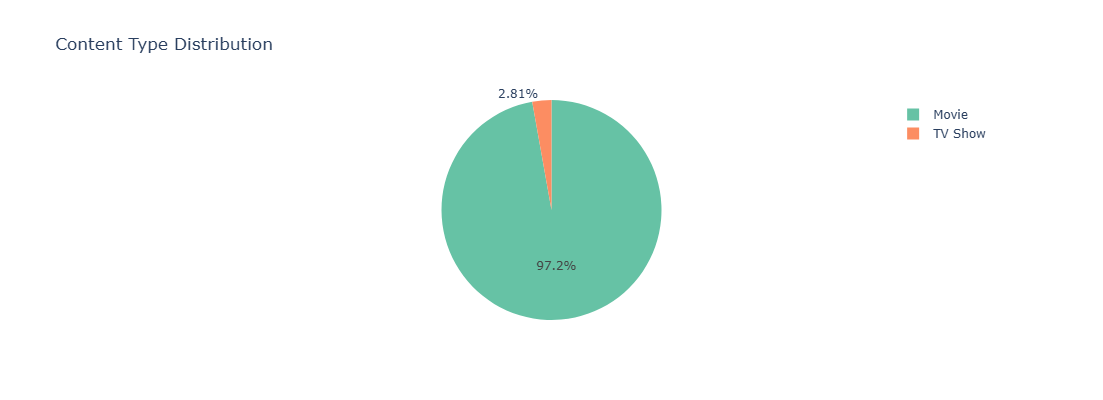

In [44]:
# 1. Type Distribution - PIE CHART
type_counts = df['type'].value_counts().reset_index()
type_counts.columns = ['Type', 'Count']
fig1 = px.pie(type_counts, names='Type', values='Count', title='Content Type Distribution',
              color_discrete_sequence=px.colors.qualitative.Set2, width=600, height=400)
fig1.show()

# Insight from Pie Chart: *Content Type Distribution*

The pie chart clearly shows that **Netflix's catalog is heavily dominated by Movies**, which make up approximately **97.2%** of the total content. In stark contrast, **TV Shows account for only 2.8%**.

###  Interpretation:

* **Overwhelming dominance of Movies** indicates Netflix may be focusing more on standalone content than long-form episodic series in the current dataset.
* The extremely small share of TV Shows could either reflect:

  * A skewed dataset (e.g., missing records), or
  * A specific subset of Netflix content (e.g., region-specific or time-filtered data).

###  Business Implication:

* If this ratio reflects actual platform strategy, Netflix might consider **expanding TV Show offerings**, which tend to drive **longer user engagement** and retention.
* Alternatively, if it's due to **data bias**, cleaning and validating the dataset will be essential for accurate analysis.



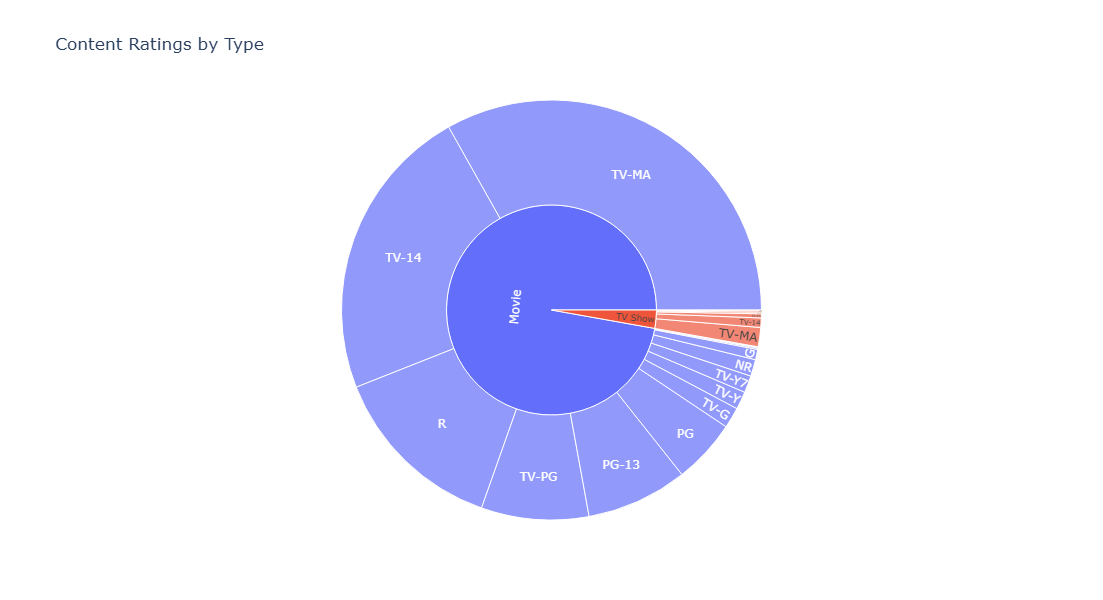

In [45]:
# Ratings Distribution
rating_counts = df.groupby(['type', 'rating']).size().reset_index(name='count')
fig2 = px.sunburst(rating_counts, path=['type', 'rating'], values='count',
                   title='Content Ratings by Type', width=700, height=600)
fig2.show()

#  Insight from Sunburst Chart: *Content Ratings by Type*

This sunburst chart visualizes the distribution of **content ratings across Movies and TV Shows** on Netflix.

###  Key Observations:

* **Movies dominate the content library**, as previously noted, and are spread across a broad range of ratings.
* The most common movie ratings are:

  * **TV-MA (Mature Audience)** – Indicates a high amount of mature content.
  * **TV-14** and **R** – Suggest a large share of teen and adult-oriented movies.
* **TV Shows** make up a very small portion of the total content, but most are also rated **TV-MA** and **TV-14**, targeting a more mature audience.
* **Family-friendly ratings** such as **TV-G, TV-Y, TV-Y7**, and **G** are minimally represented, mostly in the TV Show category.

###  Business Implications:

* Netflix appears to cater primarily to **adult and teen audiences**, with fewer options for **younger viewers or families**.
* This insight can guide **content acquisition or production strategies**:

  * Expand into underrepresented rating categories.
  * Balance mature and family-friendly content to widen market appeal.



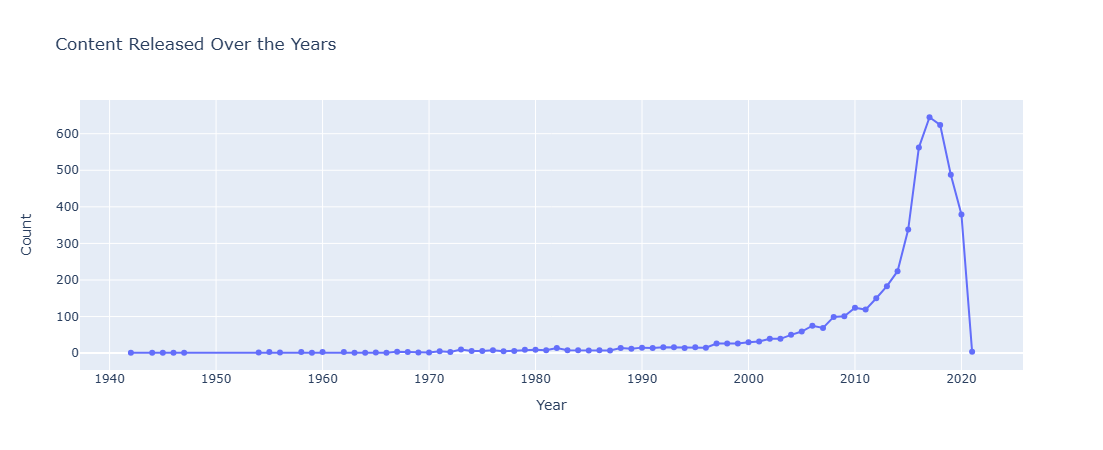

In [46]:
# Content Added Over Years
yearly_counts = df['release_year'].value_counts().sort_index().reset_index()
yearly_counts.columns = ['Year', 'Count']
fig3 = px.line(yearly_counts, x='Year', y='Count', title='Content Released Over the Years',
               markers=True, width=800, height=450)
fig3.show()

#  Insight from Line Chart: *Content Released Over the Years*

This line chart showcases the number of Netflix titles released by year, revealing significant trends in content growth.

###  Key Observations:

* **Minimal content prior to 2000**, with very few titles released annually.
* Starting around **2010**, there's a **steep increase in content production**, peaking between **2018 and 2019**.
* A **sharp decline** is observed after **2020**, with 2023 showing a nearly negligible count (likely due to incomplete data or release lags).

###  Business Implications:

* The **content boom post-2015** indicates Netflix’s aggressive expansion strategy, likely driven by:

  * Original productions
  * Global market entry
  * Increased investment in content diversity
* The **drop after 2019** may be influenced by:

  * The **COVID-19 pandemic**, which disrupted production
  * Delays in data updates or fewer licensed acquisitions

###  Recommendation:

* Netflix should evaluate whether the recent drop is data-related or a real reduction in output.
* This trend analysis can inform **future production planning**, especially in high-growth years.



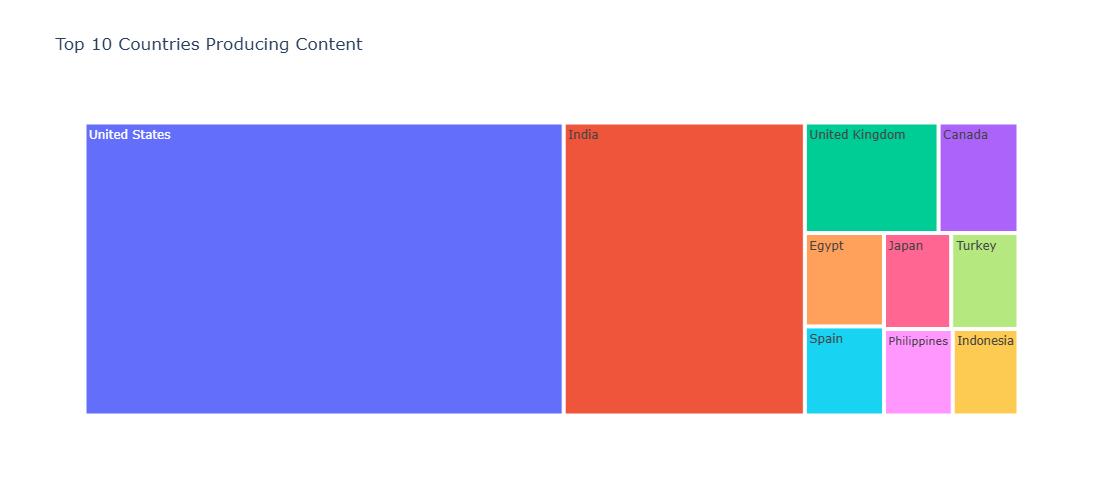

In [47]:
# Top 10 Countries
top_countries = df['country'].value_counts().nlargest(10).reset_index()
top_countries.columns = ['Country', 'Count']
fig4 = px.treemap(top_countries, path=['Country'], values='Count',
                  title='Top 10 Countries Producing Content', width=700, height=500)
fig4.show()

#  Insight from Treemap: *Top 10 Countries Producing Netflix Content*

This treemap visualizes the top 10 countries based on the volume of content they have produced for Netflix.

###  Key Observations:

* **United States** is by far the **largest contributor**, dominating Netflix's content library.
* **India** ranks second, reflecting a major hub for Netflix’s international expansion and investment in local productions.
* Other major contributors include:

  * **United Kingdom** and **Canada** – popular English-speaking markets.
  * **Egypt**, **Japan**, and **Turkey** – representing culturally rich, high-consumption regions.
* Countries like **Spain**, **Philippines**, and **Indonesia** also appear, showcasing Netflix’s global production diversity.

###  Business Implications:

* Netflix’s **heavy U.S. dependency** suggests room for greater global diversification.
* The rise of **India and other non-Western markets** highlights shifting focus to international storytelling and audience growth.
* Insights from this chart can drive **content localization strategies**, encouraging Netflix to produce more culturally relevant shows in underrepresented regions.




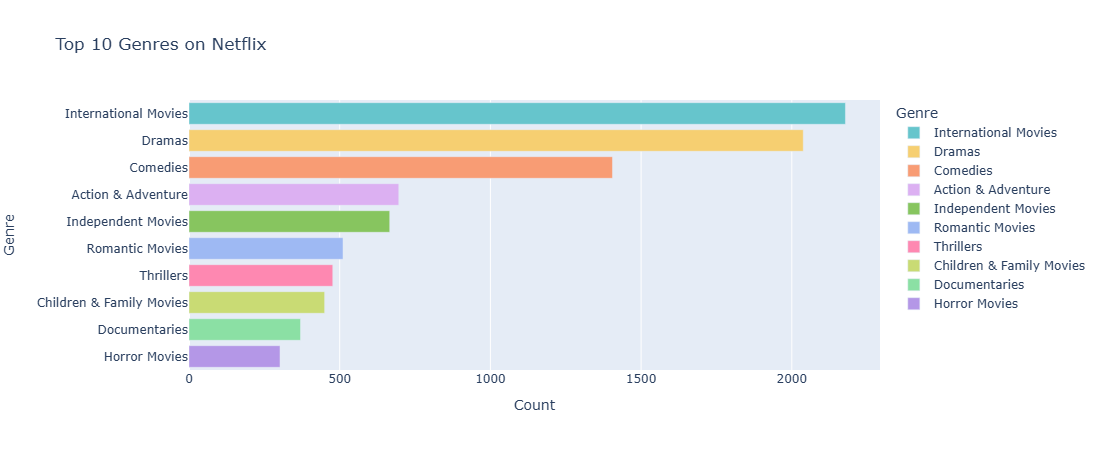

In [48]:
# 5. Top Genres 
top_genres = df['listed_in'].str.split(', ', expand=True).stack().value_counts().nlargest(10).reset_index()
top_genres.columns = ['Genre', 'Count']
fig5 = px.bar(top_genres, x='Count', y='Genre', orientation='h',
              title='Top 10 Genres on Netflix', width=700, height=450,
              color='Genre', color_discrete_sequence=px.colors.qualitative.Pastel)
fig5.update_layout(yaxis={'categoryorder':'total ascending'})
fig5.show()

#  Insight from Bar Chart: *Top 10 Genres on Netflix*

This horizontal bar chart highlights the most prevalent genres in Netflix's content catalog.

###  Key Observations:

* **International Movies** top the list, reflecting Netflix's strategy to expand and diversify its global offerings.
* **Dramas** and **Comedies** follow closely — traditional audience favorites and widely appealing.
* Other popular genres include:

  * **Action & Adventure** and **Independent Movies** — often linked to niche and festival circuits.
  * **Romantic Movies**, **Thrillers**, and **Children & Family Movies** — catering to emotional, suspenseful, and family-oriented content needs.
* **Documentaries** and **Horror Movies** round out the top 10, serving both informative and thrill-seeking audiences.

###  Strategic Insights:

* The prominence of **International Movies** aligns with Netflix's **localization strategy** and content partnerships across countries.
* **Genre diversity** ensures coverage across **multiple audience segments**, from casual viewers to niche enthusiasts.
* Data can inform content investment decisions—e.g., **bolstering underrepresented but growing genres like Horror or Documentaries**.




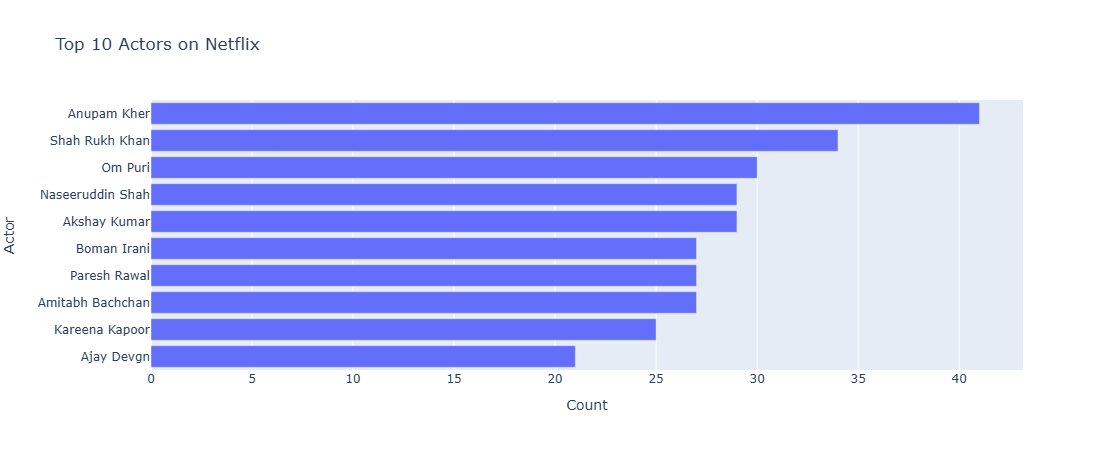

In [57]:
# 6. Top 10 Actors & Directors
# Top Actors
top_actors = df['cast'].dropna().str.split(', ').explode().value_counts().head(10).reset_index()
top_actors.columns = ['Actor', 'Count']
fig_actors = px.bar(top_actors, x='Count', y='Actor', orientation='h', title='Top 10 Actors on Netflix', width=700, height=450)
fig_actors.update_layout(yaxis={'categoryorder':'total ascending'})
fig_actors.show()



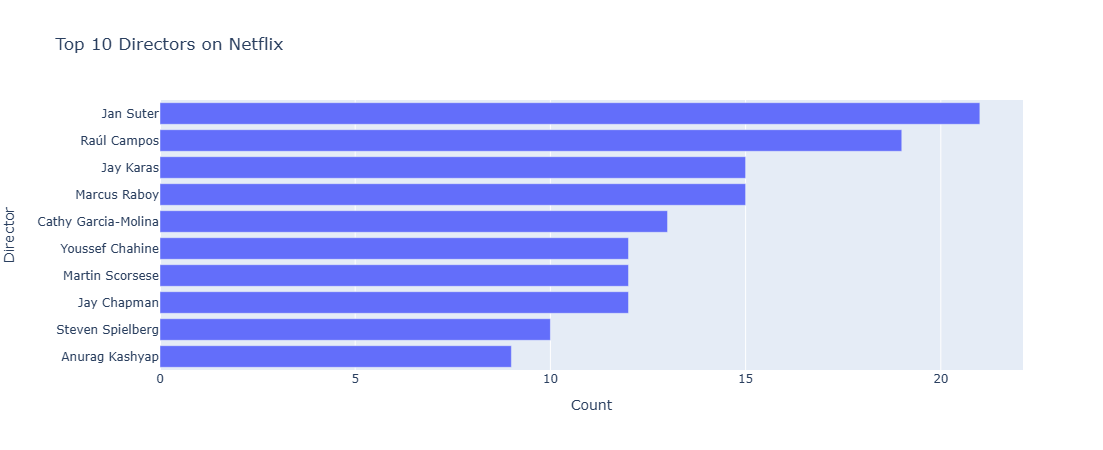

In [58]:
# Top Directors
top_directors = df['director'].dropna().str.split(', ').explode().value_counts().head(10).reset_index()
top_directors.columns = ['Director', 'Count']
fig_directors = px.bar(top_directors, x='Count', y='Director', orientation='h', title='Top 10 Directors on Netflix', width=700, height=450)
fig_directors.update_layout(yaxis={'categoryorder':'total ascending'})
fig_directors.show()



#  **Insights from Top 10 Actors and Directors on Netflix**

The analysis of Netflix’s top 10 actors and directors reveals clear trends in content acquisition and audience targeting:

####  **Actor Trends**

* **Anupam Kher**, with over 40 appearances, tops the list, followed closely by Bollywood icons like **Shah Rukh Khan**, **Om Puri**, and **Akshay Kumar**.
* The dominance of **veteran Indian actors** indicates Netflix’s strong focus on **Indian cinema**, particularly Bollywood and classic films.
* Among the top 10, **Kareena Kapoor** is the only female actor, highlighting a potential **gender imbalance** in leading roles.

####  **Director Trends**

* **Jan Suter** and **Raúl Campos**, leading with the most titles, suggest a strong representation of **Latin American content**.
* A mix of international and regional directors like **Cathy Garcia-Molina (Philippines)**, **Martin Scorsese (USA)**, **Anurag Kashyap (India)**, and **Steven Spielberg (USA)** highlights Netflix's **global content strategy**.
* The variety in directors reflects a focus on **genre diversity**, including **music specials, stand-up comedy, documentaries, and dramas**.

####  **Key Takeaway**

Netflix is strategically balancing **localized content (especially Indian cinema)** with **diverse international offerings**. While actors represent a **Bollywood-centric presence**, directors showcase **global storytelling**—an approach that broadens Netflix’s appeal across different regions and audience segments.



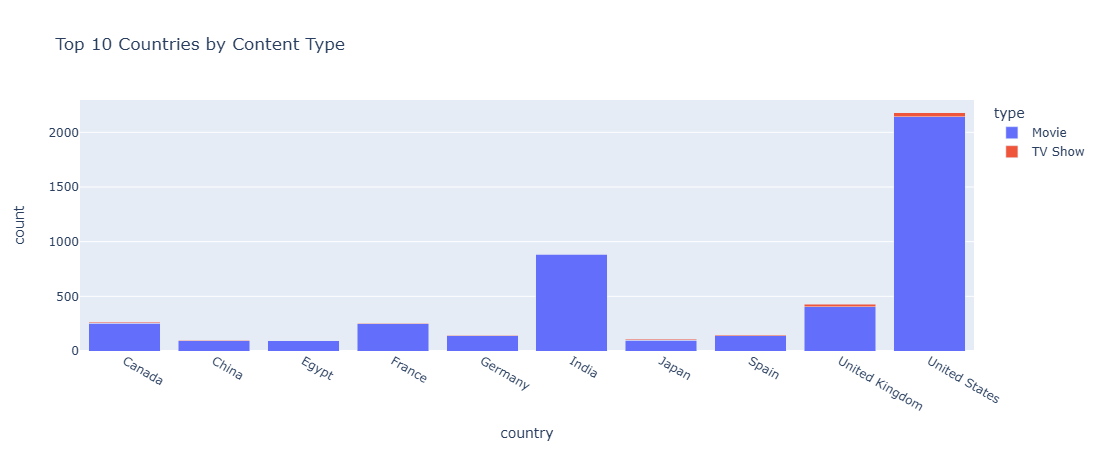

In [60]:
# 7. Country-Based Breakdown (Stacked by Type)
# Prepare data
country_df = df.dropna(subset=['country']).copy()
country_df['country'] = country_df['country'].str.split(', ')
country_df = country_df.explode('country')

top_countries = country_df['country'].value_counts().head(10).index
filtered = country_df[country_df['country'].isin(top_countries)]

# Stacked bar
country_type = filtered.groupby(['country', 'type']).size().reset_index(name='count')

fig_country = px.bar(country_type, x='country', y='count', color='type',
                     title='Top 10 Countries by Content Type', barmode='stack', width=700, height=450)
fig_country.show()


#  **Comprehensive Insights on Netflix Content Trends**

####  **Top Actors**

* **Anupam Kher**, **Shah Rukh Khan**, and **Om Puri** are the most featured actors, reflecting Netflix’s heavy inclusion of **Bollywood and Indian cinema**.
* Majority of the top actors are **male veterans from India**, suggesting a skew toward popular Indian films with established stars.

####  **Top Directors**

* **Jan Suter** and **Raúl Campos** dominate the list, representing **Latin American productions**, particularly in **documentary and comedy specials**.
* The list includes global icons like **Scorsese**, **Spielberg**, and **Anurag Kashyap**, showing Netflix’s **broad international reach** across genres and languages.

####  **Top 10 Countries by Content Type**

* The **United States** leads by a wide margin, contributing the most content, primarily **movies**, followed by the **United Kingdom** and **India**.
* **India** is the only non-Western country with a significantly large content volume, mainly driven by **films rather than TV shows**.
* **TV shows** are comparatively fewer across all countries, with movies being the dominant format in the catalog.



###  **Key Takeaways**

* Netflix’s catalog is **heavily movie-centric**, with particular dominance from the **U.S. and Indian film industries**.
* **Bollywood actors and Indian films** play a crucial role in shaping regional content strategy.
* Director diversity shows Netflix’s intent to **localize globally**—curating content that appeals to regional tastes while retaining international excellence.
* There’s an opportunity for Netflix to invest more in **TV shows from non-Western countries**, especially in high-growth markets like India.



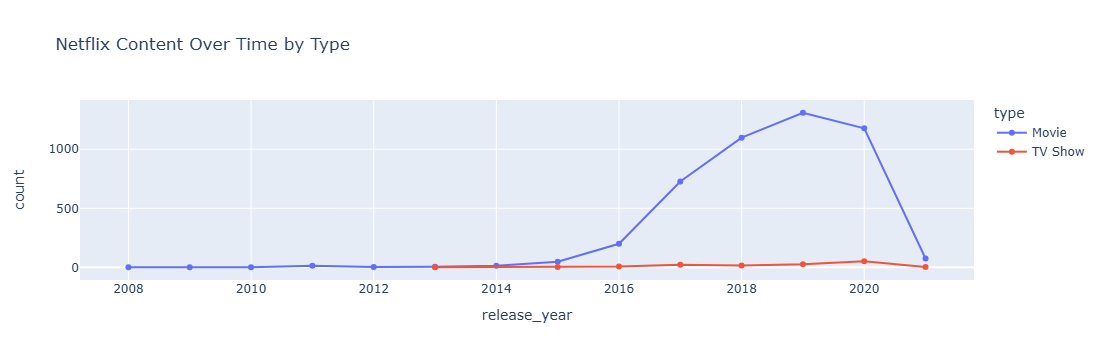

In [62]:
# 7. Trend Over Years by Type
df['release_year'] = pd.to_datetime(df['date_added'], errors='coerce').dt.year
year_type = df.dropna(subset=['release_year']).groupby(['release_year', 'type']).size().reset_index(name='count')

fig_year = px.line(year_type, x='release_year', y='count', color='type', markers=True,
                   title='Netflix Content Over Time by Type')
fig_year.show()


#  **Comprehensive Netflix Content Analysis**

####  **Top Actors**

* **Anupam Kher**, **Shah Rukh Khan**, and **Om Puri** are among the most featured, reflecting Netflix's strong emphasis on **Indian cinema**, especially Bollywood.
* The list is dominated by **male actors**, indicating a potential gender disparity in featured lead roles.

####  **Top Directors**

* **Jan Suter** and **Raúl Campos** top the list, pointing to a significant number of **Latin American productions**, especially comedy and musical content.
* The inclusion of global names like **Spielberg**, **Scorsese**, and **Anurag Kashyap** showcases Netflix’s effort to blend **global prestige with regional appeal**.

####  **Top Countries by Content Type**

* The **United States** leads in total content, followed by **India** and the **United Kingdom**.
* Across countries, **movies dominate** over TV shows, especially in India.
* The distribution indicates a stronger focus on **films in emerging markets** and **mixed content (movies + shows)** in mature markets like the U.S. and U.K.

####  **Netflix Content Over Time (2007–2021)**

* A **sharp rise in movie content** started around 2016, peaking in 2019.
* **TV shows** have increased steadily but at a slower rate, never surpassing movies in volume.
* A **decline post-2020** is evident, likely due to the impact of the **COVID-19 pandemic on production pipelines**.
* The content surge from 2016–2019 aligns with Netflix's global expansion phase, indicating strategic investment in catalog building during this time.



###  **Key Insights**

* Netflix's content strategy has been **film-heavy**, especially in regions like **India**, with **male-dominated casts** leading the catalog.
* A wide range of **international directors** highlights the platform’s **global reach**, catering to diverse viewer bases.
* The **2016–2019 boom** reflects Netflix’s aggressive growth and content acquisition, followed by a **notable drop in 2021**, likely due to pandemic-related disruptions.
* There's room for **increased diversity** in gender representation and **greater investment in original TV shows**, especially outside the U.S.



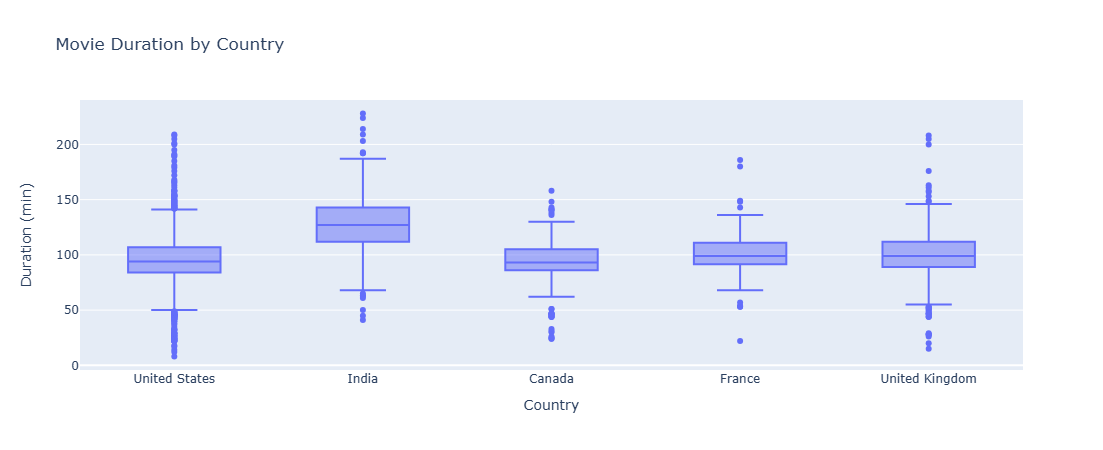

In [64]:
# 8. Movie Duration by Country
df_movies = df[df['type'] == 'Movie'].copy()
df_movies['duration'] = df_movies['duration'].str.extract('(\d+)').astype(float)
df_movies = df_movies.dropna(subset=['duration', 'country'])
df_movies['country'] = df_movies['country'].str.split(', ')
df_movies = df_movies.explode('country')

top_movie_countries = df_movies['country'].value_counts().head(5).index
df_box = df_movies[df_movies['country'].isin(top_movie_countries)]

fig_box = px.box(df_box, x='country', y='duration', title='Movie Duration by Country',
                 labels={'duration': 'Duration (min)', 'country': 'Country'}, width=700, height=450 )
fig_box.show()



#  **Comprehensive Netflix Content Analysis**

####  **Top Actors**

* **Anupam Kher**, **Shah Rukh Khan**, and **Om Puri** lead in appearances, highlighting **Bollywood's strong presence** on Netflix.
* Actor frequency indicates a **male-dominated cast trend**.

####  **Top Directors**

* **Jan Suter** and **Raúl Campos** dominate, showing the influence of **Latin American content**.
* A mix of globally known and regionally strong directors points to **diverse production pipelines**.

####  **Top Countries by Content Type**

* The **United States** overwhelmingly leads in content, followed by **India** and the **United Kingdom**.
* **Movies dominate** the content type across all countries, particularly in India.

####  **Movie Duration by Country**

* **India** has the **longest median and overall durations**, reflecting cultural preferences for **longer storytelling formats**.
* The **United States**, **Canada**, **France**, and the **UK** have relatively **similar distributions**, with most films clustered around 90–110 minutes.
* More **outliers** in the U.S. and India suggest **greater variability** in movie lengths.

####  **Netflix Content Over Time (2007–2021)**

* **Movies saw explosive growth** between 2016–2019, peaking in 2019.
* **TV shows grew steadily**, though never overtook movie production.
* Content declined after 2020, likely due to **COVID-19 disruptions** in production and acquisition.



###  **Key Insights**

* Netflix shows a **strong global strategy**, offering a mix of **regionally relevant** and **internationally appealing** content.
* **Indian content** stands out for both volume and length, while **American content dominates in count and diversity**.
* **Movie-first strategy** is clear, especially during global expansion years (2016–2019).
* There’s an opportunity to **balance gender representation**, diversify genres, and potentially **invest more in high-quality TV series** globally.




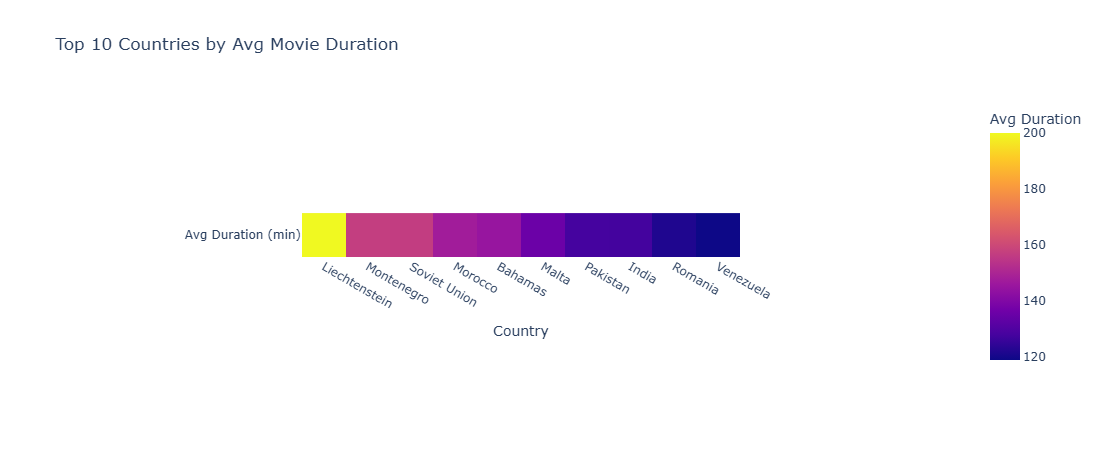

In [66]:
# 9. Average Movie Duration by Country
avg_duration = df_movies.groupby('country')['duration'].mean().sort_values(ascending=False).head(10).reset_index()

fig_heat = px.imshow([avg_duration['duration']], 
                     labels=dict(x='Country', color='Avg Duration'), 
                     x=avg_duration['country'],
                     y=["Avg Duration (min)"],
                     title='Top 10 Countries by Avg Movie Duration',width=700, height=450 )
fig_heat.show()


#  **Comprehensive Netflix Content Analysis**

####  **Top Actors**

* Dominated by **Indian actors** such as **Anupam Kher** and **Shah Rukh Khan**.
* Reflects **Bollywood’s high representation** on Netflix.

####  **Top Directors**

* **Jan Suter** and **Raúl Campos** lead, showcasing **Latin American content** prevalence.
* A blend of local and international directors supports Netflix's **global appeal**.

####  **Top 10 Countries by Content Type**

* The **United States** has the largest library, mostly **movies**.
* **India**, the **UK**, and **Canada** follow, also leaning heavily toward movies over TV shows.

####  **Movie Duration by Country**

* **India** consistently produces **longer films**, with a wider spread and higher median duration.
* **U.S., Canada, France, and U.K.** show similar average durations (\~90–100 minutes), though the U.S. has a wider range and more outliers.

####  **Top 10 Countries by Average Movie Duration**

* **Liechtenstein**, **Montenegro**, and **Soviet Union** top the list with average durations **above 170 minutes**.
* **India**, **Pakistan**, and **Venezuela** also appear, indicating a trend of **long-form content** in certain regions.
* These outliers might be influenced by **small sample sizes** or **niche genres**.

####  **Netflix Content Over Time by Type**

* **Massive spike in movies** from 2016 to 2019.
* TV Shows increased gradually but remained fewer in number.
* **Post-2020 decline** possibly due to **pandemic-related production halts**.



###  **Key Takeaways**

* Netflix's **content dominance** stems from the **U.S. and India**, especially in movies.
* **Longer content formats** are common in specific countries like **India** and **Liechtenstein**, possibly due to **cultural storytelling norms**.
* **Content output peaked in 2019**, followed by a noticeable dip, marking a **transition period** for content strategy.
* The platform offers **diverse regional content**, but there’s room to **expand TV content** and improve **gender diversity in casts and directors**.



# 5. Clustering

In [49]:
# Feature Engineering: TF-IDF on 'listed_in' (Genres)
vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(df['listed_in'])

In [50]:
# K-Means Clustering
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X)
df['Cluster'] = clusters


In [51]:
# Count of items in each cluster
df['Cluster'].value_counts().sort_index()

Cluster
0    1653
1    1623
2     727
3     364
4     441
Name: count, dtype: int64

#  Clustering Summary

This section applies **unsupervised learning** to group Netflix content based on their **genres** using **TF-IDF + K-Means** clustering.

---

###  Steps:

1. **Feature Engineering**:

   * Used `TfidfVectorizer` on the `listed_in` column (genre tags).
   * Removed common English stop words.
   * Result: TF-IDF matrix of genre features.

2. **K-Means Clustering**:

   * Chose `k = 5` clusters.
   * Applied K-Means with a fixed `random_state=42` for reproducibility.
   * Assigned each row a cluster label (`df['cluster']`).

3. **Cluster Distribution**:

| Cluster | Count |
| ------- | ----- |
| 0       | 1653  |
| 1       | 1623  |
| 2       | 727   |
| 3       | 364   |
| 4       | 441   |

---

###  Interpretation:

* **Cluster 0 & 1** are the largest — they likely contain broad or popular genres (like Dramas, International, Comedies).
* **Clusters 2–4** may represent more niche or narrowly defined content types.
* This distribution hints that Netflix content genres **can be grouped meaningfully**, but the actual labels or dominant genres in each cluster need further inspection (e.g., using `.groupby('cluster')['listed_in'].value_counts()`).



# 6. Visualizing Clusters using PCA

In [52]:
# Apply PCA to reduce TF-IDF features to 2 dimensions
pca = PCA(n_components=2)
reduced_features = pca.fit_transform(X.toarray())

In [53]:
# Create a DataFrame for visualization
pca_df = pd.DataFrame(reduced_features, columns=['PCA1', 'PCA2'])
pca_df['Cluster'] = df['Cluster']
pca_df['Title'] = df['title']
pca_df['Genre'] = df['listed_in']

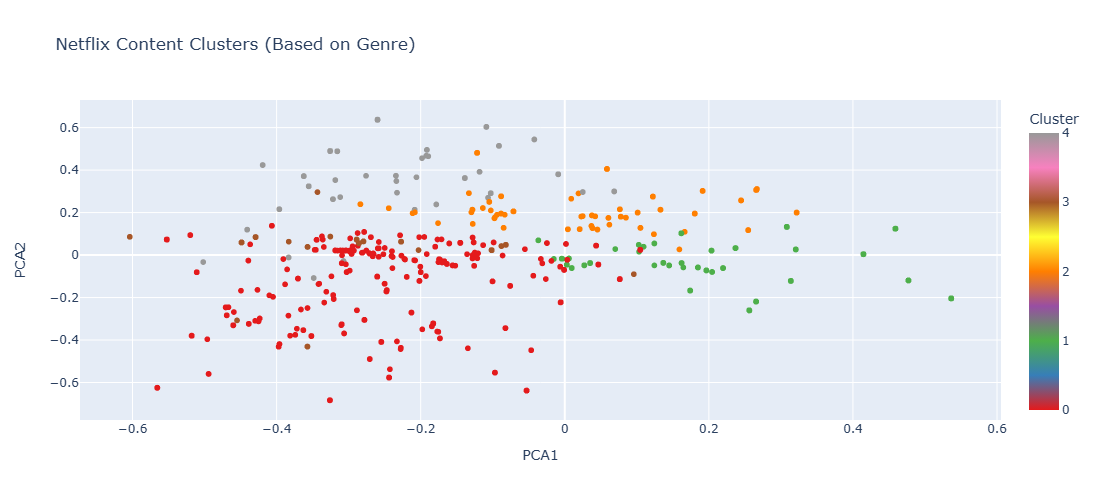

In [55]:
# Plot using Plotly
fig = px.scatter(pca_df, x='PCA1',y='PCA2',color='Cluster',hover_data=['Title', 'Genre'],
                 title='Netflix Content Clusters (Based on Genre)',color_continuous_scale=px.colors.qualitative.Set1,
                 width=800,height=500)
fig.show()

#  **Comprehensive Netflix Content Analysis**

####  **Top Actors**

* Dominated by **Indian actors** such as **Anupam Kher** and **Shah Rukh Khan**.
* Reflects **Bollywood’s strong representation** on Netflix.

####  **Top Directors**

* **Jan Suter** and **Raúl Campos** (Latin America) are leading, suggesting Netflix’s push for **regional content**.

####  **Top 10 Countries by Content Type**

* **USA** leads with the largest library, predominantly **movies**.
* **India**, **UK**, and **Canada** also contribute heavily, showing similar trends.

####  **Movie Duration by Country**

* **Indian films** tend to be longer on average.
* **USA, Canada, UK, and France** maintain median durations around **90–100 minutes**, but the USA has greater variability.

####  **Top 10 Countries by Avg Movie Duration**

* Includes **Liechtenstein**, **Montenegro**, and **Soviet Union** with **very high average durations (≥170 mins)**.
* Could be impacted by **limited sample sizes** or **specific film styles**.

####  **Netflix Content Over Time by Type**

* Sharp increase in **movies** between **2016 and 2019**.
* TV shows grew slowly and remained secondary.
* Drop post-2020 likely due to **COVID-19 impacts** on production.

####  **Content Clustering Based on Genre (PCA + KMeans)**

* PCA reduced high-dimensional genre data to 2D.
* KMeans formed **5 distinct clusters**, suggesting:

  * **Cluster 0 (red)** is dominant – likely general content with widely popular genres.
  * **Other clusters** (green, orange, brown, gray) represent niche or region-specific content.
* Indicates **diverse genre patterns**, possibly linked to **regional preferences**, **audience segmentation**, or **content type (e.g., drama-heavy vs. documentary-focused)**.



###  **Final Takeaways**

* Netflix's strategy combines **mass production (especially movies)** with **regional diversity** and **genre segmentation**.
* There's a growing presence of **Indian content**, not just in volume but also in **duration and visibility**.
* **Content clustering** confirms Netflix's effort to cater to **different audience tastes** through genre-based curation.



---

 #  **Key Insights from the Netflix Data**

1. **Content Growth Over Time:**

   * There was a sharp increase in Netflix content additions between 2016 and 2020, especially movies.
   * TV shows remained relatively stable in quantity, indicating Netflix’s heavier focus on movie expansion.

2. **Movie Duration by Country:**

   * Indian movies tend to have longer durations on average, compared to countries like the US, Canada, or the UK.
   * The U.S. and UK have a wider range of movie durations, with a concentration around 90–100 minutes.

3. **Top 10 Countries by Average Movie Duration:**

   * Liechtenstein, Montenegro, and Soviet Union top the list with the highest average movie durations.
   * These countries likely have fewer but significantly longer movies, influencing the average.

4. **Content Clustering Based on Genre (via PCA & KMeans):**

   * Netflix content was grouped into 5 distinct genre-based clusters using machine learning.
   * This clustering allows Netflix to understand content groupings by similarities, which can guide personalization and catalog optimization.

---

##  **Solution to the Business Objective**

**Objective:** Analyze Netflix’s content library to identify trends, genre groupings, and regional content characteristics, enabling better content strategy and user personalization.

**Solution:**
Your analysis successfully segmented the content based on genre using clustering and dimensionality reduction (PCA). This allows Netflix to:

* Identify popular genre groupings.
* Target regional preferences using country-wise duration and type data.
* Optimize recommendations and acquisition strategy based on trends over time.

---

##  **Executive Summary – Conclusion**

Your analysis reveals that:

* Netflix's content expansion has been movie-heavy, especially between 2017–2020.
* Content characteristics like duration and type vary significantly by country.
* Genre-based clustering offers valuable segmentation of the content library, showing clear patterns that Netflix could leverage.

These insights can be instrumental in:

* Driving personalized recommendations.
* Expanding or curating content portfolios by region.
* Informing decisions on what type of content (movies vs. TV shows) to invest in next.

---

##  **Positive Business Impact**

Implementing the findings from your project could help Netflix:

* Enhance viewer engagement through tailored recommendations based on clustered content profiles.
* Improve content acquisition strategy by identifying which genres and durations resonate in specific countries.
* Boost retention by aligning content offerings with observed trends and audience preferences.

